In [1]:
# Import necessary libraries for data handling and visualization

import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 


In [2]:
# Load customer ID and rating data from 'data.txt', assigning appropriate column names

df = pd.read_csv('data.txt', header=None, names=['cust_id', 'rating'], usecols=[0, 1])

In [3]:
# Preview the first two rows of the dataset

df.head(2)

,cust_id,rating
0,1:,NaN
1,1488844,3.0


In [4]:
df.dtypes

cust_id     object
rating     float64
dtype: object

In [5]:
# Check for missing values in the dataset


df.isnull().sum()

cust_id       0
rating     4499
dtype: int64

In [6]:
# Check for missing values in the dataset

movie_count = df.isnull().sum()
movie_count = movie_count['rating']
movie_count

4499

In [7]:
# Perform operation

customer_count = df.cust_id.nunique()
customer_count

475257

In [8]:
# Customer after removing movie count

r_customer = customer_count-movie_count


In [9]:
# Average rating count per person

(len(df)-movie_count)/r_customer

51.09581568449182

In [10]:
rating_count = df['cust_id'].count()-movie_count

In [11]:
stars = df.groupby('rating')['rating'].agg(['count'])
stars

,count
rating,
1.0,1118186
2.0,2439073
3.0,6904181
4.0,8085741
5.0,5506583


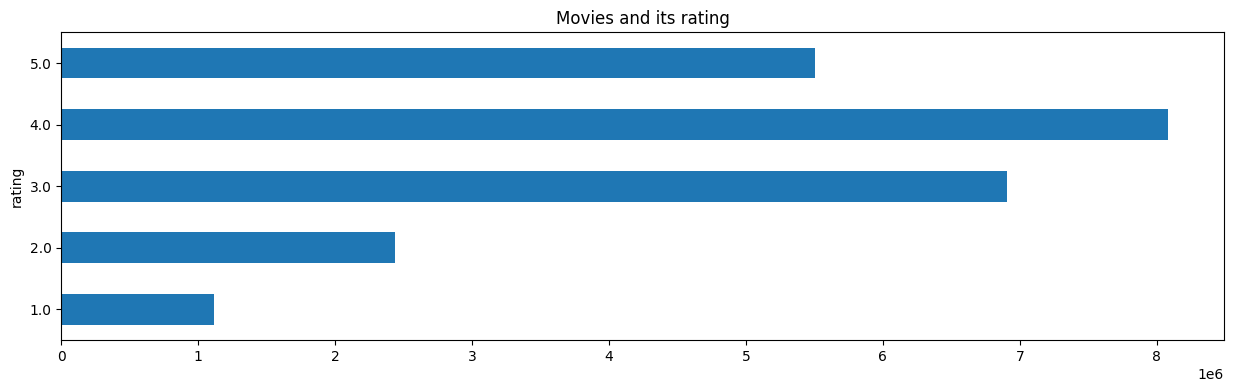

In [12]:
# Customize or show the plot

ax = stars.plot(kind='barh', legend=False, figsize=(15, 4))
plt.title('Movies and its rating')
plt.show()

In [13]:
movie_id = []

for i in df.cust_id:
    if ':' in i:
        id = int(i.replace(':', ''))
    movie_id.append(id)

In [14]:
df['movie_id'] = movie_id 

In [15]:
df.dropna(inplace=True)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   cust_id   object 
 1   rating    float64
 2   movie_id  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 734.1+ MB


In [17]:
df.cust_id = df.cust_id.astype('int')

In [18]:
# Group data and apply aggregation

movie_summary = df.groupby('movie_id')['rating'].agg(['count'])
movie_summary

,count
movie_id,
1,547
2,145
3,2012
4,142
5,1140
...,...
4495,614
4496,9519
4497,714


In [19]:
# Calculate the 20th percentile of the 'count' distribution to set a threshold for filtering less-rated movies

movie_benchmark = round(movie_summary['count'].quantile(0.2), 0)
movie_benchmark

161.0

In [20]:
# Listing the movies having rating  below threshold 
drop_movie_list = movie_summary[movie_summary['count'] < movie_benchmark].index

In [21]:
cust_summary = df.groupby('cust_id')['rating'].agg(['count'])
cust_summary

,count
cust_id,
6,153
7,195
8,21
10,49
25,4
...,...
2649404,12
2649409,10
2649421,3


In [22]:
# Determine the 20th percentile of user activity to identify and filter out infrequent reviewers

cust_benchmark = round(cust_summary['count'].quantile(0.2), 0)

In [23]:
# Listing the customers whose rating count is below the threshold

drop_custid = cust_summary[cust_summary['count'] < cust_benchmark].index
drop_custid

Index([     25,     133,     149,     177,     178,     189,     215,     267,
           299,     308,
       ...
       2649024, 2649063, 2649082, 2649146, 2649240, 2649252, 2649326, 2649343,
       2649379, 2649421],
      dtype='int32', name='cust_id', length=93752)

In [24]:
# Dropping off the customer id and movies id below threshold

n_df = df[~df['movie_id'].isin(drop_movie_list)]
n_df = n_df[~n_df['cust_id'].isin(drop_custid)]

In [25]:
n_df

,cust_id,rating,movie_id
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [26]:
# Import core components from the Surprise library for building a collaborative filtering recommendation system

from surprise import Reader, Dataset, SVD
from surprise.model_selection import train_test_split

In [27]:
# Initialize the Reader object with default settings to parse rating data for the Surprise library
reader = Reader()

# Instantiate the SVD (Singular Value Decomposition) algorithm for collaborative filtering
alg_svd = SVD()


In [ ]:
# Load the user-movie-rating records into a Surprise dataset using the specified Reader

data = Dataset.load_from_df(n_df, reader)


In [29]:
# Step 2: Train/test split
trainset, testset = train_test_split(data, test_size=0.25)


In [30]:
alg_svd.fit(trainset)

In [31]:
# Generate top-N movie recommendations for a given user using a trained SVD model
def top_reccommendation(id: int, top_k: int, test_file):
    # Filter the dataset to get movies rated by the target user
    user_rating = n_df[n_df.cust_id == id]
    
    # Create a copy of the test dataset to avoid modifying the original
    user_data = test_file.copy()
    
    # Exclude movies that should be dropped (e.g., low popularity or low rating count)
    user_data = user_data[~user_data['Movie_Id'].isin(drop_movie_list)]
    
    # Predict ratings for each movie in the filtered list using the SVD model
    user_data['Pred_score'] = user_data.Movie_Id.apply(lambda x: alg_svd.predict(id, x).est)
    
    # Sort movies by predicted rating in descending order
    sorted_user = user_data.sort_values(by='Pred_score', ascending=False)
    
    # Return the top-N recommended movies
    return sorted_user[:top_k]


In [32]:
# Reading the new movies list, 

df_title = pd.read_csv('data.csv', header=None, encoding='ISO-8859-1', names = ['Movie_Id',"Year","Title"],usecols =[0,1,2])

In [33]:
top_reccommendation(1331154, 5, df_title)

,Movie_Id,Year,Title,Pred_score
24,25,1997.0,Inspector Morse 31: Death Is Now My Neighbour,4.035748
4,5,2004.0,The Rise and Fall of ECW,4.026284
27,28,2002.0,Lilo and Stitch,4.000399
0,1,2003.0,Dinosaur Planet,3.998982
7,8,2004.0,What the #$*! Do We Know!?,3.964701
